[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ImagingDataCommons/idc-monai/blob/main/monai_contribution/idc_dataset.ipynb)

# Using NCI Imaging Data Commons with MONAI

Copyright 2026 Imaging Data Commons

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0

---

## What is IDC?

[NCI Imaging Data Commons (IDC)](https://portal.imaging.datacommons.cancer.gov/) is a free, cloud-hosted repository of publicly available cancer imaging data maintained by the National Cancer Institute (NCI). It provides:

- **~100 TB** of radiology (CT, MR, PET) and pathology images across 160+ cancer collections
- **No sign-up or authentication required** — data is openly accessible
- **Expert and AI-generated annotations** (e.g., organ segmentations) paired with images
- **Standardized format** — all data uses DICOM, the medical imaging industry standard
- **Cloud-native storage** — data lives in Google Cloud Storage (GCS) buckets, so downloads are fast
- **Accompanying tools** - you can search, visualize, and subset the data

## What is `idc-index`?

[`idc-index`](https://github.com/ImagingDataCommons/idc-index) is a lightweight Python package that lets you search and download IDC data without any cloud account or special credentials. It ships with a local metadata index — a set of DuckDB tables describing every image series in IDC — so you can run SQL queries locally to find exactly the data you need before downloading anything.

## What this tutorial covers

This tutorial shows how to:
1. Query IDC metadata with SQL to find cancer imaging data
2. Download DICOM images and segmentations with one function call
3. Load the data into MONAI for AI/ML preprocessing
4. Work with DICOM Segmentation (DICOM-SEG) objects and their rich metadata

> **Tip**: This tutorial was created using [idc-claude-skill](https://github.com/ImagingDataCommons/idc-claude-skill) — an AI assistant skill for navigating IDC data and the `idc-index` API.

## Setup

Install required packages:
- `monai` — Medical Open Network for AI, the ML framework used here
- `idc-index` — Query and download IDC data (includes local metadata index)
- `itk` / `itkwasm-dicom` — ITK-based DICOM readers used by MONAI's `ITKReader` and our custom DICOM-SEG loader

In [1]:
!pip install -q monai idc-index itk itkwasm-dicom

# Restart runtime after installing ITK (required for ITK to load properly)
import sys
if "google.colab" in sys.modules:
    try:
        import itk
    except ImportError:
        print("Restarting runtime to load ITK...")
        import os
        os.kill(os.getpid(), 9)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.3/77.3 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.0/28.0 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/28.5 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 98.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.1/31.1 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 14.3 M

## Setup imports

In [2]:
import os
import tempfile
from pathlib import Path
from typing import Hashable, Mapping

import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from idc_index import IDCClient

from monai.config import KeysCollection
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    Spacingd,
    ScaleIntensityRanged,
    MapTransform,
)
from monai.data import Dataset, DataLoader, MetaTensor
from monai.data.image_reader import ITKReader
import monai

monai.config.print_config()

MONAI version: 1.6.0
Numpy version: 2.1.3
Pytorch version: 2.11.0+cpu
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: eccefc57550b111ed781d82249dfe77872a0e918
MONAI __file__: /usr/local/lib/python3.13/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: 5.4.7
Nibabel version: 5.4.2
scikit-image version: 0.25.2
scipy version: 1.16.3
Pillow version: 11.3.0
Tensorboard version: 2.20.0
gdown version: 5.2.2
TorchVision version: 0.26.0+cpu
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 2.2.3
einops version: 0.8.2
transformers version: 5.16.1
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://monai.readthedocs.io/en/latest/installation.html#i

## 1. Discover Data with `idc-index`

`idc-index` ships with a built-in local metadata index — a DuckDB database containing one row per DICOM series in IDC. You query it using standard SQL via `client.sql_query()`. **No internet connection is needed for queries** — only for downloading actual image files, or for installing optional components of `idc-index`.

The primary table is `index`, which has one row per DICOM series and includes columns like:
- `SeriesInstanceUID` — unique identifier for a series (used for downloading)
- `collection_id` — which dataset the series belongs to (e.g., `lidc_idri`, `nlst`)
- `PatientID`, `StudyInstanceUID` — standard DICOM identifiers
- `Modality` — imaging type (`CT`, `MR`, `SEG`, `RTSTRUCT`, etc.)
- `series_size_MB` — download size in megabytes
- `license_short_name` — data license (important before use in a project)

Additional index tables (loaded on demand with `fetch_index()`) extend this with collection-level info, segmentation metadata, volume geometry, metadata specific to pathology images, etc (see [this documentation page](https://idc-index.readthedocs.io/en/latest/indices_reference.html) for details).

In [5]:
# IDCClient is the main entry point for idc-index.
client = IDCClient()

# IDC releases versioned snapshots of the metadata.
# The version number tells you which data release the local index reflects.
print(f"IDC version: {client.get_idc_version()}")

# Query the primary 'index' table to see the overall scale of IDC.
# 'collection_id' groups series by dataset; 'PatientID' is the DICOM patient identifier.
stats = client.sql_query("""
    SELECT COUNT(DISTINCT collection_id) as collections,
           COUNT(DISTINCT PatientID) as patients,
           COUNT(DISTINCT SeriesInstanceUID) as series,
           SUM(series_size_MB) as size_mb,
           ROUND(SUM(series_size_MB) / 1e6, 2) as size_tb
    FROM index
""")
print(f"Collections: {stats.iloc[0]['collections']}, Patients: {stats.iloc[0]['patients']}, Total size: {stats.iloc[0]['size_tb']}TB")

IDC version: v24
Collections: 176.0, Patients: 85362.0, Total size: 99.27TB


In [33]:
from idc_index import IDCClient

client = IDCClient()

client.fetch_index("collections_index")

# 验证表是否已存在
print(client.sql_query("SHOW TABLES").to_string(index=False))

# 1. 查看当前数据库里有哪些表
print("=== SHOW TABLES ===")
tables = client.sql_query("SHOW TABLES")
print(tables.to_string(index=False))

# 2. 查看 collections_index 的列定义
print("\n=== DESCRIBE collections_index ===")
try:
    desc = client.sql_query("DESCRIBE collections_index")
    print(desc.to_string(index=False))
except Exception as e:
    print("DESCRIBE collections_index 失败：", e)

# 3. 用 information_schema 查 collections_index 的列名和类型
print("\n=== columns of collections_index ===")
cols = client.sql_query("""
    SELECT column_name, data_type
    FROM information_schema.columns
    WHERE table_name = 'collections_index'
    ORDER BY ordinal_position
""")
print(cols.to_string(index=False))

# 4. 专门找包含 cancer 的列，不区分大小写
print("\n=== columns containing 'cancer' in collections_index ===")
cancer_cols = client.sql_query("""
    SELECT column_name, data_type
    FROM information_schema.columns
    WHERE table_name = 'collections_index'
      AND lower(column_name) LIKE '%cancer%'
""")
print(cancer_cols.to_string(index=False))

# 5. 查看 index 表的列，确认 join 字段是否存在
print("\n=== columns of index ===")
idx_cols = client.sql_query("""
    SELECT column_name, data_type
    FROM information_schema.columns
    WHERE table_name = 'index'
    ORDER BY ordinal_position
""")
print(idx_cols.to_string(index=False))

                name
   collections_index
               index
prior_versions_index
=== SHOW TABLES ===
                name
   collections_index
               index
prior_versions_index

=== DESCRIBE collections_index ===
    column_name                                                                                                                                                                                                                                                                            column_type null  key default extra
collection_name                                                                                                                                                                                                                                                                                VARCHAR  YES None    None  None
  collection_id                                                                                                                           

In [38]:
# 'collections_index' is a table with one row per IDC collection.
# It adds collection-level metadata not in the per-series 'index' t able,
# such as CancerTypes, Subjects count, and collection descriptions.

# Fetch the collections_index table
client.fetch_index("collections_index")

# Join collections_index with the per-series index to filter by both cancer type and modality.
# The 'index' table has Modality per series; collections_index has CancerTypes per collection.
lung_collections = client.sql_query("""
    SELECT c.collection_id, c.Subjects, c.Cancer_Types,
           COUNT(DISTINCT CASE WHEN i.Modality = 'CT' THEN i.SeriesInstanceUID END) as ct_series
    FROM collections_index c
    JOIN index i ON c.collection_id = i.collection_id
    WHERE c.Cancer_Types LIKE '%Lung%'
    GROUP BY c.collection_id, c.Subjects, c.Cancer_Types
    HAVING ct_series > 0
    ORDER BY c.Subjects DESC
    LIMIT 5
""")
print("Lung CT collections:")
print(lung_collections.to_string(index=False))

Lung CT collections:
             collection_id  subjects                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 cancer_types  ct_series
                      nlst     26410  

In [40]:
# 'volume_geometry_index' is a supplemental table that adds pre-computed
# geometric quality flags for each CT/MR series — for example:
#   regularly_spaced_3d_volume = TRUE means the slices form a clean 3D volume
#   (uniform spacing, no gaps, no duplicate positions).
# Filtering on this flag avoids downloading series that won't load cleanly into MONAI.
client.fetch_index("volume_geometry_index")

# Select a few small CT series that form well-formed 3D volumes.
# We join 'index' (series metadata) with 'volume_geometry_index' (geometry flags).
# ORDER BY series_size_MB is not here, but LIMIT 3 keeps the demo download small.
series_df = client.sql_query("""
    SELECT index.SeriesInstanceUID, PatientID, Modality,
           ROUND(series_size_MB, 2) as size_mb
    FROM index
    JOIN volume_geometry_index USING (SeriesInstanceUID)
    WHERE regularly_spaced_3d_volume = TRUE AND Modality = 'CT'
    LIMIT 3
""")
print(f"Found {len(series_df)} CT series")
print(series_df.to_string(index=False))

Found 3 CT series
                                               SeriesInstanceUID            PatientID Modality  size_mb
1.3.6.1.4.1.14519.5.2.1.9999.103.1249103157349783283756782145243 COVID-19-AR-16407187       CT    53.31
1.3.6.1.4.1.14519.5.2.1.9999.103.2644204237118861651930136844707 COVID-19-AR-16407187       CT   317.78
1.3.6.1.4.1.14519.5.2.1.9999.103.3232439442170564874652627681894 COVID-19-AR-16407187       CT    90.70


## 2. Download DICOM Data

`download_from_selection()` fetches DICOM files directly from IDC's Google Cloud Storage buckets. No account or credentials are needed — all IDC data is publicly accessible.

Files are organized on disk according to the `dirTemplate` pattern. Using `%SeriesInstanceUID` creates one subdirectory per series, which is what MONAI's `ITKReader` expects when loading a DICOM series.

In [8]:
# Create a temporary directory to hold downloaded DICOM files.
data_dir = tempfile.mkdtemp(prefix="idc_monai_")
series_uids = list(series_df['SeriesInstanceUID'])

print(f"Downloading {len(series_uids)} series...")
# download_from_selection() accepts a list of SeriesInstanceUIDs and fetches
# all DICOM files for those series from IDC's GCS buckets.
# dirTemplate="%SeriesInstanceUID" puts each series in its own subdirectory —
# required because MONAI's ITKReader reads a directory to reconstruct a 3D volume.
client.download_from_selection(
    seriesInstanceUID=series_uids,
    downloadDir=data_dir,
    dirTemplate="%SeriesInstanceUID"
)
print("Done!")

Done!


## 3. Load with MONAI Transforms

MONAI's `LoadImaged` with `ITKReader` directly loads DICOM series from directories.

In [47]:
# Define transforms for CT preprocessing
# Use ITKReader explicitly to load DICOM series from directories
transforms = Compose([
    LoadImaged(keys=["image"], reader=ITKReader()),
    EnsureChannelFirstd(keys=["image"]),
    Orientationd(keys=["image"], axcodes="RAS"),
    Spacingd(keys=["image"], pixdim=(1.5, 1.5, 2.0)),
    ScaleIntensityRanged(keys=["image"], a_min=-175, a_max=250,
                         b_min=0.0, b_max=1.0, clip=True),
])

# Create dataset
data_dicts = [{"image": os.path.join(data_dir, uid)} for uid in series_uids]
dataset = Dataset(data=data_dicts, transform=transforms)
print(data_dicts)

# Load sample
sample = dataset[0]
print(f"Image shape: {sample['image'].shape}")
print(f"Value range: [{sample['image'].min():.2f}, {sample['image'].max():.2f}]")

monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


[{'image': '/tmp/idc_monai_97pu9drq/1.3.6.1.4.1.14519.5.2.1.9999.103.1249103157349783283756782145243'}, {'image': '/tmp/idc_monai_97pu9drq/1.3.6.1.4.1.14519.5.2.1.9999.103.2644204237118861651930136844707'}, {'image': '/tmp/idc_monai_97pu9drq/1.3.6.1.4.1.14519.5.2.1.9999.103.3232439442170564874652627681894'}]
Image shape: torch.Size([1, 325, 325, 151])
Value range: [0.00, 1.00]


## 4. Visualize

torch.Size([325, 325, 151])


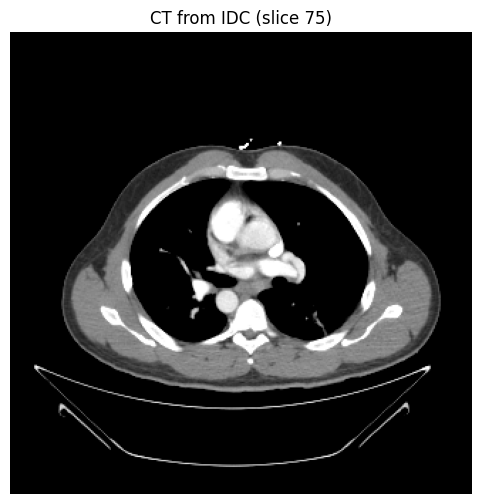

In [45]:

image = sample['image'][0]
print(image.shape)
z = image.shape[2] // 2

plt.figure(figsize=(6, 6))
plt.imshow(image[:, :, z].T, cmap='gray', origin='lower')
plt.title(f'CT from IDC (slice {z})')
plt.axis('off')
plt.show()


## 5. Loading DICOM Segmentations

IDC contains DICOM Segmentation (DICOM-SEG) objects. These are different from regular DICOM series:
- **Enhanced multiframe**: All slices in a single file
- **Cannot use ITKReader**: Standard readers don't support this format
- **Segment metadata**: Each segment has label, description, and recommended display color

We define a custom `LoadDicomSegd` transform that:
1. Uses `itkwasm-dicom` (wraps dcmqi) for robust DICOM-SEG reading
2. Derives the affine matrix directly from DICOM metadata (direction cosines, spacing, origin) — no axis flipping
3. Orientation is fully encoded in the affine via the direction cosine matrix
4. Extracts segment colors from DICOM metadata for visualization

> **Note**: CT and SEG may have different affines when acquired with different orientations (common with AI-generated segmentations like TotalSegmentator). Apply `Orientationd` to normalize both to a common orientation before voxel-level overlay.

In [48]:
# 'seg_index' is a supplemental index table with one row per DICOM Segmentation series in IDC.
# It adds metadata specific to segmentations that isn't in the primary 'index' table:
#   segmented_SeriesInstanceUID — the SeriesInstanceUID of the CT/MR image that was segmented
#   AlgorithmName              — the tool that created the segmentation (e.g., TotalSegmentator)
#   total_segments             — how many anatomical structures are labeled in the file
# fetch_index() downloads and caches it locally; once cached it won't re-download.
client.fetch_index("seg_index")

# Find CT series that have TotalSegmentator segmentations.
# TotalSegmentator is an AI model that auto-segments 100+ anatomical structures.
# The JOIN links each segmentation back to its source CT via segmented_SeriesInstanceUID.
# We sort by image size (ASC) so the demo downloads the smallest available pair.
paired = client.sql_query("""
    SELECT src.SeriesInstanceUID as image_uid,
           seg.SeriesInstanceUID as seg_uid,
           src.collection_id, seg.total_segments,
           ROUND(src.series_size_MB, 2) as image_mb
    FROM seg_index seg
    JOIN index src ON seg.segmented_SeriesInstanceUID = src.SeriesInstanceUID
    WHERE src.Modality = 'CT'
      AND seg.AlgorithmName LIKE '%TotalSegmentator%'
    ORDER BY src.series_size_MB ASC
    LIMIT 3
""")
print("CT with TotalSegmentator segmentations:")
print(paired.to_string(index=False))

CT with TotalSegmentator segmentations:
                                                  image_uid                                                   seg_uid collection_id  total_segments  image_mb
 1.2.840.113654.2.55.39501032054040159252741883490811009228 1.2.276.0.7230010.3.1.3.313263360.23926.1706319815.161829          nlst              47     26.32
1.2.840.113654.2.55.134877680474542655199243531560181528016 1.2.276.0.7230010.3.1.3.313263360.31910.1706312185.595733          nlst              73     26.32
1.2.840.113654.2.55.296129646159215067393462057349853219678 1.2.276.0.7230010.3.1.3.313263360.35421.1706312631.378111          nlst              62     26.32


In [49]:
# Download one image-segmentation pair
demo_pair = paired.iloc[0]
seg_dir = tempfile.mkdtemp(prefix="idc_seg_")

print(f"Downloading image and segmentation pair...")
client.download_from_selection(
    seriesInstanceUID=[demo_pair['image_uid'], demo_pair['seg_uid']],
    downloadDir=seg_dir,
    dirTemplate="%SeriesInstanceUID"
)
print("Done!")

Done!


In [68]:
import itkwasm_dicom

class LoadDicomSegd(MapTransform):
    """Load DICOM Segmentation (DICOM-SEG) files using ITKWasm.

    DICOM-SEG is an enhanced multiframe DICOM format that stores segmentation
    masks with segment metadata including recommended display colors.

    The affine matrix is derived directly from DICOM metadata (direction cosines,
    spacing, origin) with LPS→RAS conversion applied to match MONAI's ITKReader
    convention. No axis flipping is performed — orientation is fully encoded in
    the affine via the direction cosine matrix.
    """

    def __init__(self, keys: KeysCollection, allow_missing_keys: bool = False):
        super().__init__(keys, allow_missing_keys)

    def _find_dcm_file(self, path: Path) -> Path:
        """Find .dcm file in directory or return path if already a file."""
        if path.is_file():
            return path
        dcm_files = list(path.glob("*.dcm"))
        if not dcm_files:
            raise FileNotFoundError(f"No .dcm files found in {path}")
        return dcm_files[0]

    def _build_affine(self, spacing, origin, direction) -> np.ndarray:
        """Build 4x4 affine matrix from DICOM spatial metadata.

        Converts from ITK/DICOM LPS convention to MONAI's RAS-like convention
        by negating X and Y world coordinates (LPS→RAS). No axis flips are
        applied — orientation is fully encoded in the affine via the direction
        cosine matrix.

        Args:
            spacing:   Voxel spacing (X, Y, Z) as returned by itkwasm
            origin:    Physical coordinates of voxel [0,0,0] in LPS
            direction: 3x3 direction cosine matrix D where D[i,j] is the
                       component of voxel-axis-j's unit vector along LPS
                       physical axis i. ITK affine formula:
                       world_lps = D @ diag(spacing) @ voxel + origin
        """
        lps_to_ras = np.diag([-1., -1., 1.])
        affine = np.eye(4)
        affine[:3, :3] = lps_to_ras @ direction @ np.diag(spacing)
        affine[:3, 3] = lps_to_ras @ origin
        return affine

    def __call__(self, data: Mapping[Hashable, any]) -> dict[Hashable, any]:
        d = dict(data)
        for key in self.key_iterator(d):
            path = Path(d[key])
            dcm_file = self._find_dcm_file(path)

            # Read using ITKWasm
            seg_image, overlay_info = itkwasm_dicom.read_segmentation(dcm_file)


            # ITKWasm returns array in (Z, Y, X) order but metadata in (X, Y, Z) order.
            # Transpose to (X, Y, Z) to match metadata — this is a layout convention,
            # not an orientation flip.
            seg_array = np.asarray(seg_image.data).copy()
            seg_array = np.transpose(seg_array, (2, 1, 0))

            # Build affine from spatial metadata
            spacing = np.array(seg_image.spacing)
            origin = np.array(seg_image.origin)
            direction = np.array(seg_image.direction).reshape(3, 3)

            affine = self._build_affine(spacing, origin, direction)

            # Make contiguous (array may be non-contiguous after transpose)
            seg_array = np.ascontiguousarray(seg_array)

            # Create MONAI MetaTensor with metadata
            meta_tensor = MetaTensor(seg_array)
            meta_tensor.affine = affine
            meta_tensor.meta["filename_or_obj"] = str(dcm_file)
            meta_tensor.meta["overlay_info"] = overlay_info
            meta_tensor.meta["original_channel_dim"] = "no_channel"

            d[key] = meta_tensor
            d[f"{key}_meta_dict"] = dict(meta_tensor.meta)

        return d

# Load CT with MONAI's ITKReader
ct_transforms = Compose([
    LoadImaged(keys=["image"], reader=ITKReader()),
    EnsureChannelFirstd(keys=["image"]),
])

# Load SEG with our custom LoadDicomSegd
seg_transforms = Compose([
    LoadDicomSegd(keys=["label"]),
    EnsureChannelFirstd(keys=["label"]),
])

# Load both
image_path = os.path.join(seg_dir, demo_pair['image_uid'])
seg_path = os.path.join(seg_dir, demo_pair['seg_uid'])
print(demo_pair['image_uid'])
print(demo_pair['seg_uid'])

ct_data = ct_transforms({"image": image_path})
seg_data = seg_transforms({"label": seg_path})

ct_image = ct_data["image"]
seg_label = seg_data["label"]

print(f"CT image shape: {ct_image.shape}")
print(f"Segmentation shape: {seg_label.shape}")
print(f"Unique labels: {torch.unique(seg_label)[:10].tolist()}...")  # First 10 labels

1.2.840.113654.2.55.39501032054040159252741883490811009228
1.2.276.0.7230010.3.1.3.313263360.23926.1706319815.161829
CT image shape: torch.Size([1, 512, 512, 50])
Segmentation shape: torch.Size([1, 512, 512, 50])
Unique labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...


In [67]:
path = os.path.join(seg_dir, demo_pair['seg_uid'])
dcm_file = list(Path(path).glob("*.dcm"))[0]
print(dcm_file)
seg_image, overlay_info = itkwasm_dicom.read_segmentation(dcm_file)
print("type:", type(seg_image))
print("size (Z,Y,X):", seg_image.size)        # itkwasm 的属性
print("spacing:", seg_image.spacing)
print("origin:", seg_image.origin)
print("direction:", seg_image.direction)
print("data shape:", np.asarray(seg_image.data).shape)
print("dtype:", np.asarray(seg_image.data).dtype)
print("unique:", np.unique(np.asarray(seg_image.data))[:11])
for info in overlay_info:
  print(info)

/tmp/idc_seg_e5yc1m01/1.2.276.0.7230010.3.1.3.313263360.23926.1706319815.161829/10cd7640-81ba-4810-b853-53c92c82e66a.dcm
type: <class 'itkwasm.image.Image'>
size (Z,Y,X): [512, 512, 50]
spacing: [0.747, 0.747, 2]
origin: [-196.875, 182.498276, 1439.5]
direction: [[ 1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
data shape: (50, 512, 512)
dtype: int16
unique: [ 0  1  2  3  4  5  6  7  8  9 10]
BodyPartExamined
ClinicalTrialCoordinatingCenterName
ClinicalTrialSeriesID
ClinicalTrialTimePointID
ContentCreatorName
InstanceNumber
SeriesDescription
SeriesNumber
segmentAttributes


dcm_file: /tmp/idc_seg_e5yc1m01/1.2.276.0.7230010.3.1.3.313263360.23926.1706319815.161829/10cd7640-81ba-4810-b853-53c92c82e66a.dcm
type: <class 'itkwasm.image.Image'>
size  (X,Y,Z): [512, 512, 50]
spacing: [0.747, 0.747, 2]
origin: [-196.875, 182.498276, 1439.5]
direction:
 [[ 1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
raw data shape (Z,Y,X): (50, 512, 512)
dtype: int16
unique: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47]
seg shape (X,Y,Z): (512, 512, 50)

--- overlay_info ---
<class 'list'> 47
{'SegmentAlgorithmName': 'TotalSegmentator v1.5.6', 'SegmentAlgorithmType': 'AUTOMATIC', 'SegmentDescription': 'TotalSegmentator 1 : spleen', 'SegmentLabel': 'Spleen', 'SegmentedPropertyCategoryCodeSequence': {'CodeMeaning': 'Anatomical Structure', 'CodeValue': '123037004', 'CodingSchemeDesignator': 'SCT'}, 'SegmentedPropertyTypeCodeSequence': {'CodeMeaning': 'Spleen', 'CodeValue': '78961009', '

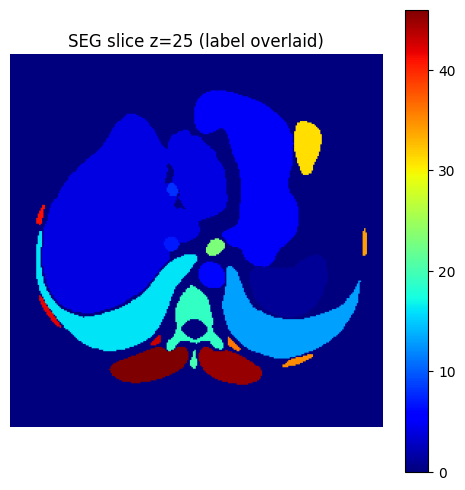

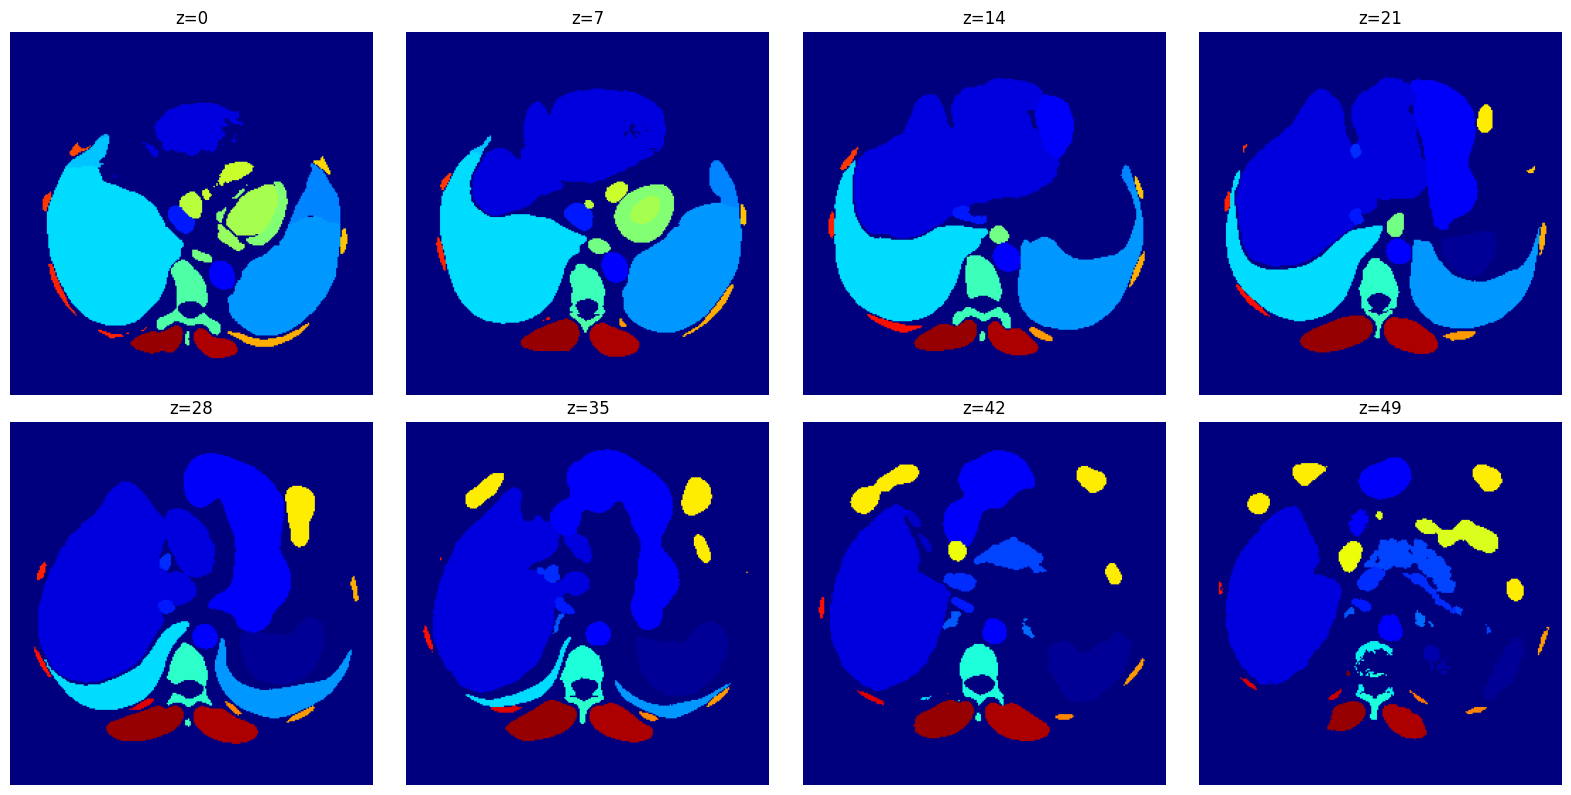

foreground labels: [np.int16(1), np.int16(2), np.int16(3), np.int16(4), np.int16(5), np.int16(6), np.int16(7), np.int16(8), np.int16(9), np.int16(10), np.int16(11), np.int16(12), np.int16(13), np.int16(14), np.int16(15), np.int16(16), np.int16(17), np.int16(18), np.int16(19), np.int16(20), np.int16(21), np.int16(22), np.int16(23), np.int16(24), np.int16(25), np.int16(26), np.int16(27), np.int16(28), np.int16(29), np.int16(30), np.int16(31), np.int16(32), np.int16(33), np.int16(34), np.int16(35), np.int16(36), np.int16(37), np.int16(38), np.int16(39), np.int16(40), np.int16(41), np.int16(42), np.int16(43), np.int16(44), np.int16(45), np.int16(46), np.int16(47)]


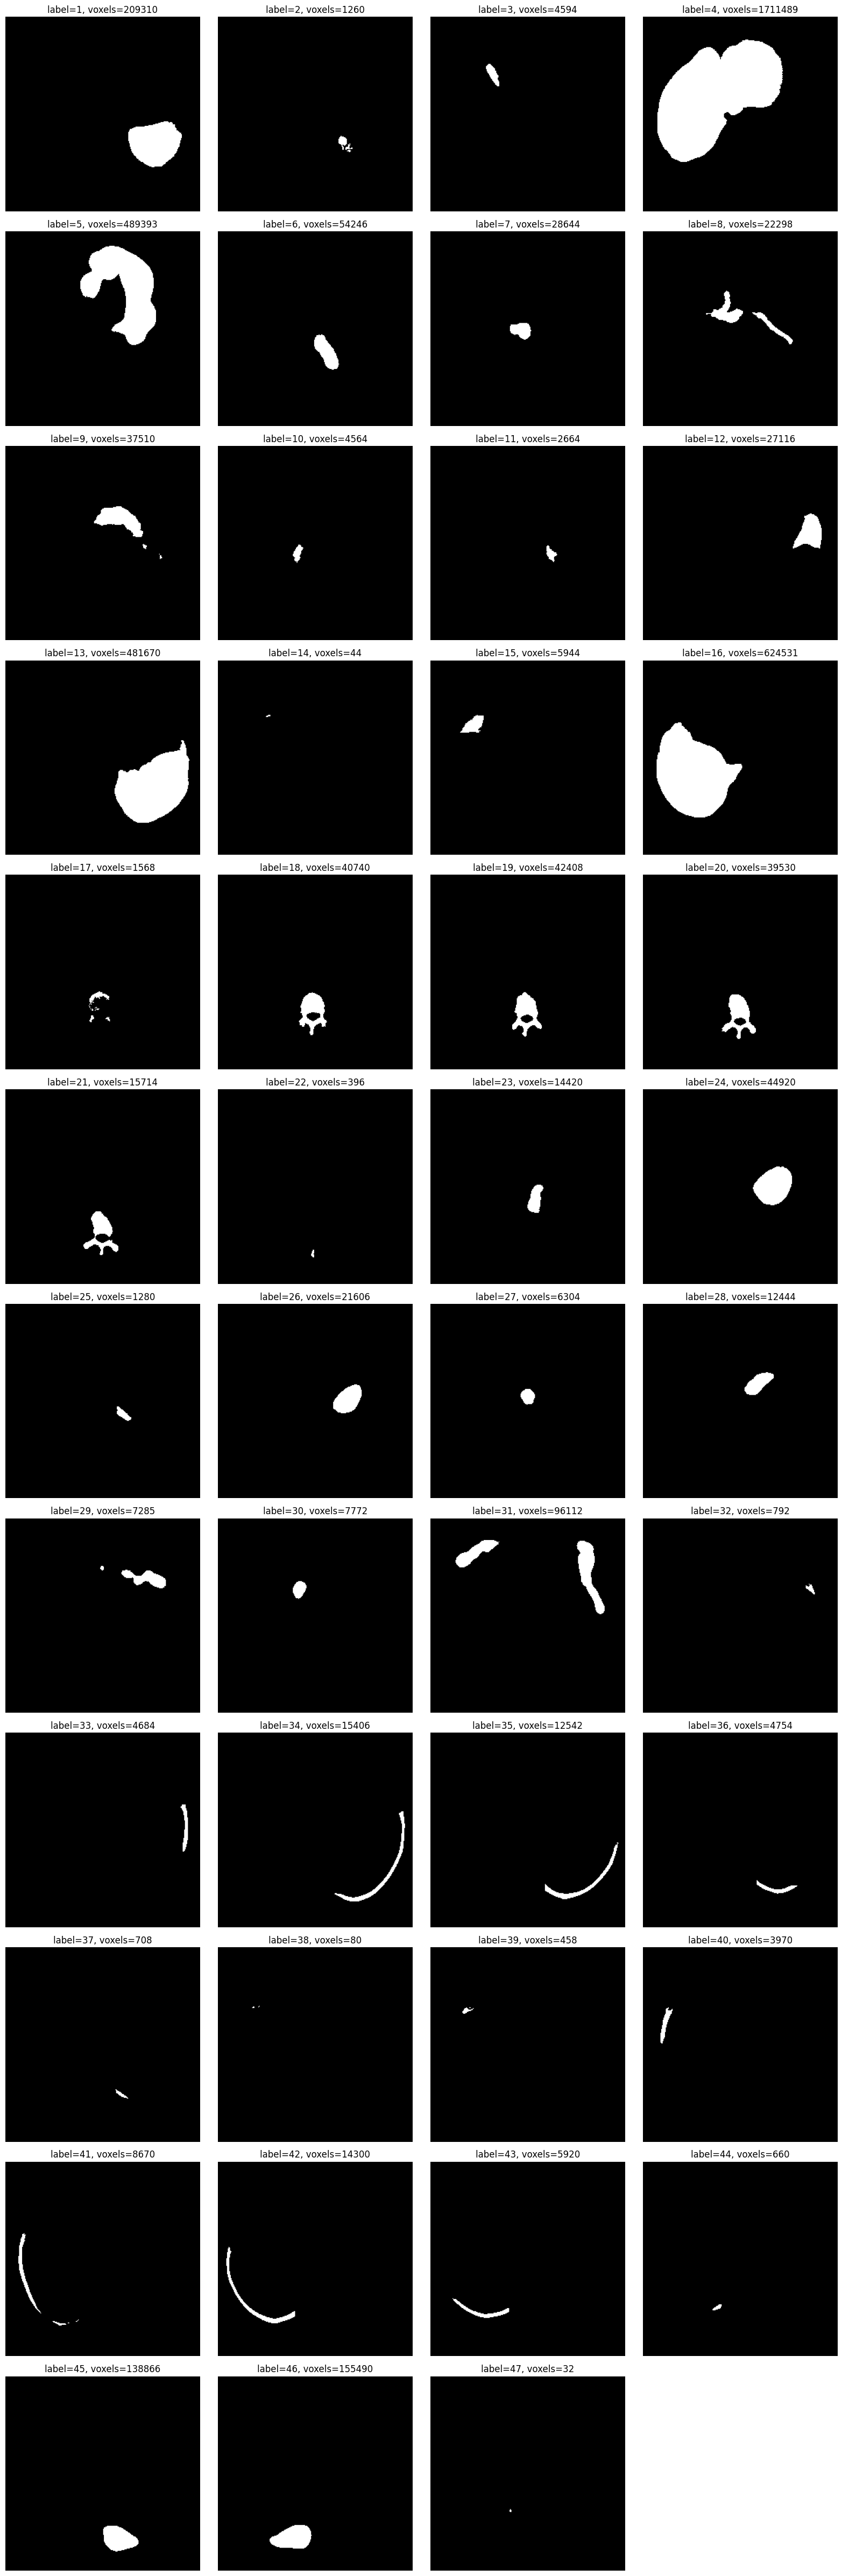

In [77]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import itkwasm_dicom

# ---------- 1. 找 dcm 文件 ----------
path = os.path.join(seg_dir, demo_pair['seg_uid'])
p = Path(path)
dcm_file = p if p.is_file() else next(p.glob("*.dcm"))
print("dcm_file:", dcm_file)

# ---------- 2. 读取 ----------
seg_image, overlay_info = itkwasm_dicom.read_segmentation(dcm_file)

# ---------- 3. 打印信息 ----------
print("type:", type(seg_image))
print("size  (X,Y,Z):", seg_image.size)          # itkwasm 是 (X,Y,Z)
print("spacing:", seg_image.spacing)
print("origin:", seg_image.origin)
print("direction:\n", np.array(seg_image.direction).reshape(3, 3))

raw = np.asarray(seg_image.data)                  # (Z, Y, X)
print("raw data shape (Z,Y,X):", raw.shape)
print("dtype:", raw.dtype)
print("unique:", np.unique(raw))

# 转成 (X, Y, Z)，与 MONAI 一致
seg_xyz = np.transpose(raw, (2, 1, 0))
print("seg shape (X,Y,Z):", seg_xyz.shape)

# ---------- 4. overlay_info ----------
print("\n--- overlay_info ---")
segs = overlay_info["segmentAttributes"][0]
print(type(segs), len(segs))
for s in segs:
    print(s)
print(overlay_info)
for info, v in overlay_info.items():
    print(f"{info}:{v}\n")

# ---------- 5. 可视化：单个 mask ----------
# seg_xyz[:, :, z] 取第 z 层，显示为 XY 平面
z = seg_xyz.shape[2] // 2
plt.figure(figsize=(6, 6))
plt.imshow(seg_xyz[:, :, z].T, cmap="jet", origin="lower")
plt.title(f"SEG slice z={z} (label overlaid)")
plt.colorbar()
plt.axis("off")
plt.show()

# ---------- 6. 可视化：多层栅格 ----------
n = 8
zs = np.linspace(0, seg_xyz.shape[2] - 1, n).astype(int)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, z in zip(axes.ravel(), zs):
    ax.imshow(seg_xyz[:, :, z].T, cmap="jet", origin="lower", vmin=0, vmax=seg_xyz.max())
    ax.set_title(f"z={z}")
    ax.axis("off")
plt.tight_layout()
plt.show()

# ---------- 7. 按 segment 分别可视化（每个 label 一张图） ----------
labels = [l for l in np.unique(seg_xyz) if l != 0]
print("foreground labels:", labels)

n = len(labels)
cols = min(4, n)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = np.atleast_2d(axes)

for i, lbl in enumerate(labels):
    ax = axes.ravel()[i]
    mask = (seg_xyz == lbl)                 # (X,Y,Z) bool
    # 做最大强度投影到 XY 平面，看这个 segment 的整体分布
    proj = mask.any(axis=2).astype(np.uint8)
    ax.imshow(proj.T, cmap="gray", origin="lower")
    ax.set_title(f"label={lbl}, voxels={mask.sum()}")
    ax.axis("off")

for j in range(len(labels), rows * cols):
    axes.ravel()[j].axis("off")

plt.tight_layout()
plt.show()

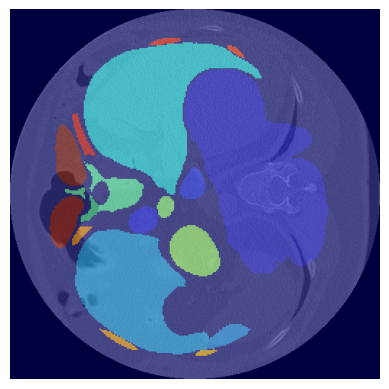

In [56]:
import matplotlib.pyplot as plt

z = ct_image.shape[-1] // 2
z = 10
plt.imshow(ct_image[0, :, :, z], cmap="gray")
plt.imshow(seg_label[0, :, :, z], cmap="jet", alpha=0.5)
plt.axis("off")
plt.show()

In [79]:
import itkwasm_dicom
from pathlib import Path

# 假设 dicom_series_dir 是你图片中下面那个多文件目录的路径
dicom_series_dir = os.path.join(seg_dir, demo_pair['image_uid'])

# 1. 获取目录下所有 .dcm 文件的路径列表
dcm_files = [str(p) for p in Path(dicom_series_dir).glob("*.dcm")]

# 2. 调用函数读取序列
# input_images: 文件路径列表
# single_sorted_series: 如果确定文件已按空间顺序排列，可设为 True；一般设为 False 让库自动排序
image_volume, sorted_filenames = itkwasm_dicom.read_image_dicom_file_series(
    input_images=dcm_files,
    single_sorted_series=False
)

# 3. 查看结果
print("Image Volume type:", type(image_volume))
print("Size (X,Y,Z):", image_volume.size)
print("Spacing:", image_volume.spacing)
print("Origin:", image_volume.origin)
print("Data shape (Z,Y,X):", image_volume.data.shape)

# sorted_filenames 是库自动排序后的文件列表，可以打印确认
print("Sorted filenames:", sorted_filenames)
print("len of sorted filenames:", len(sorted_filenames))

Image Volume type: <class 'itkwasm.image.Image'>
Size (X,Y,Z): [512, 512, 50]
Spacing: [0.747, 0.747, 2]
Origin: [-196.875, -199.2187, 1341.5]
Data shape (Z,Y,X): (50, 512, 512)
Sorted filenames: ['/tmp/idc_seg_e5yc1m01/1.2.840.113654.2.55.39501032054040159252741883490811009228/406c8943-bfc4-4d9d-afed-03a1daf62a51.dcm', '/tmp/idc_seg_e5yc1m01/1.2.840.113654.2.55.39501032054040159252741883490811009228/3a1e81df-a41b-48bd-83da-3bd0715b941b.dcm', '/tmp/idc_seg_e5yc1m01/1.2.840.113654.2.55.39501032054040159252741883490811009228/b05f2c65-a5d1-4711-b4a1-6dcb8a115524.dcm', '/tmp/idc_seg_e5yc1m01/1.2.840.113654.2.55.39501032054040159252741883490811009228/d839c8b2-19f3-4dce-aa72-663f33213508.dcm', '/tmp/idc_seg_e5yc1m01/1.2.840.113654.2.55.39501032054040159252741883490811009228/b99fc678-729c-45af-96c0-239490e124ae.dcm', '/tmp/idc_seg_e5yc1m01/1.2.840.113654.2.55.39501032054040159252741883490811009228/c5c7eb06-9289-4682-a5e3-9be10409399a.dcm', '/tmp/idc_seg_e5yc1m01/1.2.840.113654.2.55.3950103205

单文件: /tmp/idc_seg_e5yc1m01/1.2.840.113654.2.55.39501032054040159252741883490811009228/7f8e5e7b-9e27-4a16-89c0-cdad3eeb7645.dcm
单文件 shape: (1, 512, 512)
序列对应层 shape: (512, 512)
完全相同: True
最大差异: 0
不同像素数: 0


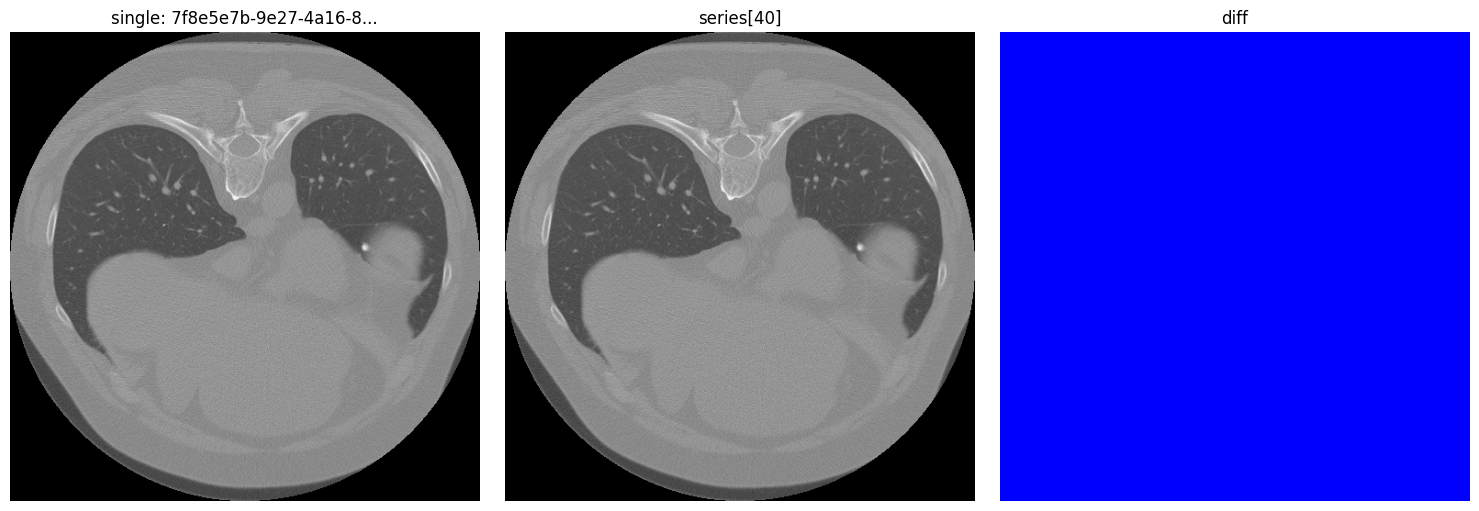

In [94]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- 4. 单独加载其中一个 .dcm 做对比 ----------
mid_idx = len(sorted_filenames) // 2          # 取中间那层
mid_idx = 40                              # 手动设置
single_file = sorted_filenames[mid_idx]
print("单文件:", single_file)

single_vol, _ = itkwasm_dicom.read_image_dicom_file_series(
    input_images=[single_file],
    single_sorted_series=True,
)
single_arr = np.asarray(single_vol.data)      # (1, Y, X)
series_arr = np.asarray(image_volume.data)    # (Z, Y, X)

# 取序列中对应那一层
series_slice = series_arr[mid_idx]
single_slice = single_arr[0]

# ---------- 5. 数值对比 ----------
print("单文件 shape:", single_arr.shape)
print("序列对应层 shape:", series_slice.shape)
print("完全相同:", np.array_equal(single_slice, series_slice))
print("最大差异:", int(np.abs(single_slice.astype(np.int32) - series_slice.astype(np.int32)).max()))
print("不同像素数:", int(np.sum(single_slice != series_slice)))

# ---------- 6. 可视化 ----------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(single_slice, cmap="gray", origin="lower")
axes[0].set_title(f"single: {Path(single_file).name[:20]}...")
axes[0].axis("off")

axes[1].imshow(series_slice, cmap="gray", origin="lower")
axes[1].set_title(f"series[{mid_idx}]")
axes[1].axis("off")

diff = single_slice.astype(np.int32) - series_slice.astype(np.int32)
axes[2].imshow(diff, cmap="bwr", origin="lower")
axes[2].set_title("diff")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [84]:
print("series metadata keys:", list(image_volume.metadata.keys()))
for k, v in image_volume.metadata.items():
    print(f"{k}: {v}")

# ---------- 单文件的元数据 ----------
print("\n===== 单文件元数据 =====")
print("type(metadata):", type(single_vol.metadata))
print("metadata keys:", list(single_vol.metadata.keys()))

# 全部打印（可能很长）
for k, v in single_vol.metadata.items():
    print(f"{k}: {v}")

series metadata keys: []

===== 单文件元数据 =====
type(metadata): <class 'dict'>
metadata keys: []


In [90]:
#!pip install pydicom
import numpy as np

ds = pydicom.dcmread(single_file)

print("pydicom PixelSpacing (row,col):", ds.PixelSpacing)
print("pydicom ImagePositionPatient:", ds.ImagePositionPatient)
print("pydicom ImageOrientationPatient:", ds.ImageOrientationPatient)

print("\nitkwasm spacing (X,Y,Z):", single_vol.spacing)
print("itkwasm origin:", single_vol.origin)
print("itkwasm direction:\n", np.array(single_vol.direction).reshape(3, 3))

import pydicom

# 单文件
ds = pydicom.dcmread(single_file)
print(ds)                            # 打印全部 tag

# 挑常用字段
for name in [
    "Modality", "SeriesDescription", "PatientName",
    "PixelSpacing", "SliceThickness", "SpacingBetweenSlices",
    "ImagePositionPatient", "ImageOrientationPatient", "SliceLocation",
    "Rows", "Columns", "RescaleSlope", "RescaleIntercept",
]:
    if name in ds:
        print(f"{name}: {ds.get(name)}")

pydicom PixelSpacing (row,col): [0.747, 0.747]
pydicom ImagePositionPatient: [-196.875000, -199.218700, 1391.500000]
pydicom ImageOrientationPatient: [1.000000, 0.000000, 0.000000, 0.000000, 1.000000, 0.000000]

itkwasm spacing (X,Y,Z): [0.747, 0.747, 1]
itkwasm origin: [-196.875, -199.2187, 1391.5]
itkwasm direction:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 192
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.840.113654.2.55.188756321383995017871157001485499957502
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.40.0.13.1.1.1
(0002,0013) Implementation Version Name         SH: 'dcm4che-1.4.31'
-------------------------------------------------
(0008,0008) Image Type  

In [16]:
# Print affines — they may differ when CT and SEG have different direction matrices.
# Both are correct: each faithfully encodes the spatial metadata from its DICOM file.
# Use Orientationd to normalize to a common orientation before voxel-level overlay.
print("CT affine:")
print(ct_image.affine)
print("\nSEG affine:")
print(seg_label.affine)

affines_match = torch.allclose(ct_image.affine, seg_label.affine, atol=1e-4)
if affines_match:
    print("\nAffines match — CT and SEG share the same acquisition orientation.")
else:
    print("\nAffines differ — CT and SEG have different acquisition orientations.")
    print("Apply Orientationd(axcodes='RAS') to both before voxel-level overlay.")

CT affine:
tensor([[-7.4700e-01,  0.0000e+00,  0.0000e+00,  1.9688e+02],
        [ 0.0000e+00, -7.4700e-01,  0.0000e+00,  1.9922e+02],
        [ 0.0000e+00,  0.0000e+00,  2.0000e+00,  1.3415e+03],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00]],
       dtype=torch.float64)

SEG affine:
tensor([[-7.4700e-01,  0.0000e+00,  0.0000e+00,  1.9688e+02],
        [ 0.0000e+00,  7.4700e-01,  0.0000e+00, -1.8250e+02],
        [ 0.0000e+00,  0.0000e+00, -2.0000e+00,  1.4395e+03],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00]],
       dtype=torch.float64)

Affines differ — CT and SEG have different acquisition orientations.
Apply Orientationd(axcodes='RAS') to both before voxel-level overlay.


## 5.1 Exploring Segment Metadata

DICOM SEG files contain rich metadata about each segment, including:
- **SegmentLabel**: Human-readable name (e.g., "Liver", "Spleen")
- **SegmentedPropertyCategoryCodeSequence**: Category (e.g., "Anatomical Structure", "Tumor")
- **SegmentedPropertyTypeCodeSequence**: Specific type using standardized codes (e.g., SNOMED-CT)
- **recommendedDisplayRGBValue**: Display color for visualization
- **labelID**: Integer label value in the segmentation array

In [95]:
def get_segment_info(overlay_info):
    """Extract segment information from DICOM SEG overlay_info.

    Args:
        overlay_info: Dictionary from LoadDicomSegd containing segmentAttributes

    Returns:
        List of dicts with segment details (label_id, name, category, type, color)
    """
    segment_attrs = overlay_info.get("segmentAttributes", [[]])

    # Flatten segment attributes (may be nested in groups)
    all_segments = []
    for group in segment_attrs:
        all_segments.extend(group)

    segments = []
    for seg in all_segments:
        # Extract category (e.g., "Anatomical Structure", "Morphologically Altered Structure")
        category_seq = seg.get("SegmentedPropertyCategoryCodeSequence", {})
        category = category_seq.get("CodeMeaning", "Unknown")

        # Extract type (e.g., "Liver", "Spleen") with coding scheme
        type_seq = seg.get("SegmentedPropertyTypeCodeSequence", {})
        seg_type = type_seq.get("CodeMeaning", "Unknown")
        type_code = type_seq.get("CodeValue", "")
        coding_scheme = type_seq.get("CodingSchemeDesignator", "")

        # Extract modifier if present (e.g., "Left", "Right")
        modifier_seq = seg.get("SegmentedPropertyTypeModifierCodeSequence", {})
        modifier = modifier_seq.get("CodeMeaning", "") if modifier_seq else ""

        segments.append({
            "label_id": seg.get("labelID", 0),
            "name": seg.get("SegmentLabel", "Unknown"),
            "category": category,
            "type": seg_type,
            "type_code": f"{coding_scheme}:{type_code}" if type_code else "",
            "modifier": modifier,
            "color_rgb": seg.get("recommendedDisplayRGBValue", [128, 128, 128]),
            "algorithm": seg.get("SegmentAlgorithmName", ""),
        })

    return sorted(segments, key=lambda x: x["label_id"])

# Extract segment information
overlay_info = seg_data.get('label_meta_dict', {}).get('overlay_info', {})
segments = get_segment_info(overlay_info)

print(f"Found {len(segments)} segments in DICOM SEG:\n")
print(f"{'ID':<4} {'Name':<25} {'Category':<25} {'Type':<20} {'Code'}")
print("-" * 100)
for seg in segments[:15]:  # Show first 15
    print(f"{seg['label_id']:<4} {seg['name']:<25} {seg['category']:<25} {seg['type']:<20} {seg['type_code']}")

if len(segments) > 15:
    print(f"... and {len(segments) - 15} more segments")

Found 47 segments in DICOM SEG:

ID   Name                      Category                  Type                 Code
----------------------------------------------------------------------------------------------------
1    Spleen                    Anatomical Structure      Spleen               SCT:78961009
2    Left Kidney               Anatomical Structure      Kidney               SCT:64033007
3    Gallbladder               Anatomical Structure      Gallbladder          SCT:28231008
4    Liver                     Anatomical Structure      Liver                SCT:10200004
5    Stomach                   Anatomical Structure      Stomach              SCT:69695003
6    Aorta                     Anatomical Structure      Aorta                SCT:15825003
7    Inferior vena cava        Anatomical Structure      Inferior vena cava   SCT:64131007
8    Portal vein and splenic vein Anatomical Structure      Portal vein and splenic vein SCT:110765007
9    Pancreas                  Anatomical S

In [96]:
# Create a lookup dictionary: label_id -> segment name
# Useful for interpreting model predictions or filtering specific structures
label_to_name = {seg["label_id"]: seg["name"] for seg in segments}

# Normalize both CT and SEG to RAS orientation before visualization.
# CT and SEG may have different direction matrices (different acquisition orientations),
# so the same voxel index maps to different world positions without reorientation.
ct_ras = Orientationd(keys=["image"], axcodes="RAS")(ct_data)["image"]
seg_ras = Orientationd(keys=["label"], axcodes="RAS")(seg_data)["label"]

ct_np = ct_ras[0].numpy()
seg_np = seg_ras[0].numpy()

# Find matching z-slices via world coordinates so the overlay is anatomically correct.
# The SEG and CT z-axes may still have different extents after RAS reorientation.
def voxel_to_world(affine, voxel):
    return (np.array(affine) @ np.append(voxel, 1))[:3]

def world_to_voxel(affine, world):
    return (np.linalg.inv(np.array(affine)) @ np.append(world, 1))[:3]

# Find SEG z-slice at the midpoint of the labeled region
z_slices_with_labels = np.where(seg_np.sum(axis=(0, 1)) > 0)[0]
seg_mid_z = int(z_slices_with_labels[len(z_slices_with_labels) // 2]) if len(z_slices_with_labels) > 0 else seg_np.shape[2] // 2

# Map SEG midpoint z to CT z via world coordinates
seg_mid_world = voxel_to_world(seg_ras.affine, [0, 0, seg_mid_z])
ct_mid_voxel = world_to_voxel(ct_ras.affine, seg_mid_world)
z_mid = int(np.clip(np.round(ct_mid_voxel[2]), 0, ct_np.shape[2] - 1))

# Show which segments are present in the matched slice
seg_slice_check = seg_np[:, :, seg_mid_z]
labels_in_slice = [int(l) for l in np.unique(seg_slice_check) if l > 0]

print(f"Segments visible in SEG slice {seg_mid_z} (mapped to CT slice {z_mid}):")
for label_id in labels_in_slice[:10]:
    seg_info = next((s for s in segments if s["label_id"] == label_id), None)
    if seg_info:
        color = seg_info["color_rgb"]
        print(f"  Label {label_id}: {seg_info['name']:<20} (RGB: {color})")

if len(labels_in_slice) > 10:
    print(f"  ... and {len(labels_in_slice) - 10} more")

monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


Segments visible in SEG slice 25 (mapped to CT slice 25):
  Label 1: Spleen               (RGB: [157, 108, 162])
  Label 4: Liver                (RGB: [221, 130, 101])
  Label 5: Stomach              (RGB: [160, 139, 76])
  Label 6: Aorta                (RGB: [224, 97, 76])
  Label 7: Inferior vena cava   (RGB: [110, 165, 54])
  Label 8: Portal vein and splenic vein (RGB: [0, 151, 206])
  Label 13: Left Lower lobe of lung (RGB: [242, 150, 232])
  Label 16: Right Lower lobe of lung (RGB: [212, 191, 32])
  Label 19: T11 vertebra         (RGB: [16, 164, 144])
  Label 20: T10 vertebra         (RGB: [26, 97, 228])
  ... and 9 more


__array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
__array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.


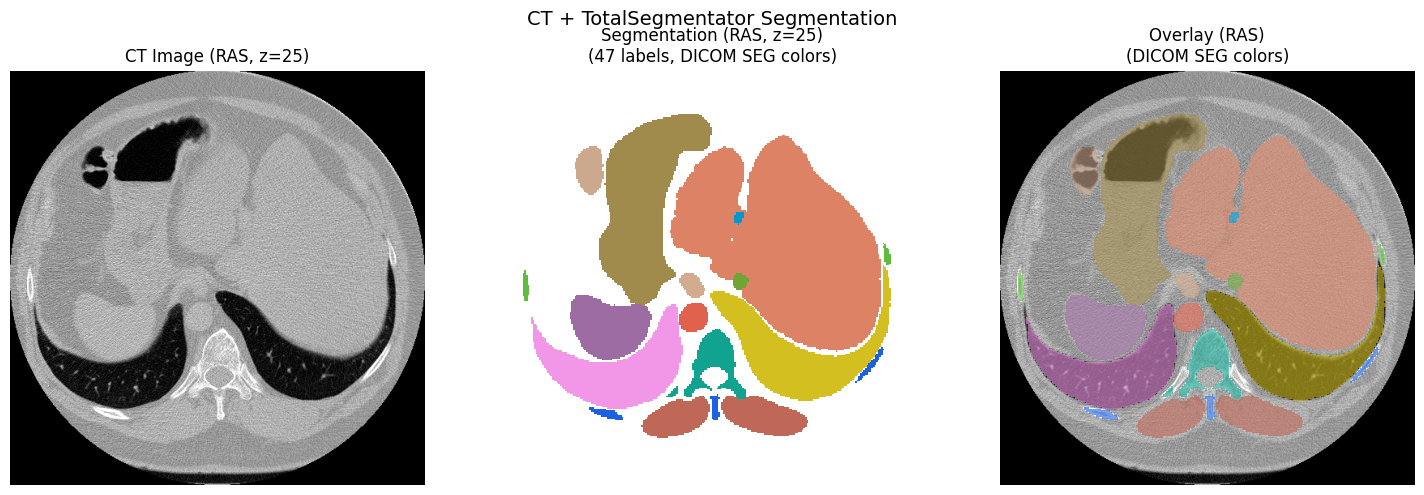


✓ Segmentation loaded with LoadDicomSegd and overlaid after RAS reorientation!
  Colors extracted from DICOM SEG recommendedDisplayRGBValue.


In [99]:
def build_seg_colormap(overlay_info):
    """Build a matplotlib colormap from DICOM SEG segment colors.

    Args:
        overlay_info: Dictionary from LoadDicomSegd containing segmentAttributes

    Returns:
        ListedColormap with colors for each segment label
    """
    segment_attrs = overlay_info.get("segmentAttributes", [[]])

    # Flatten segment attributes (may be nested in groups)
    all_segments = []
    for group in segment_attrs:
        all_segments.extend(group)

    if not all_segments:
        return plt.cm.nipy_spectral

    max_label = max(seg.get("labelID", 0) for seg in all_segments)

    # Build RGBA color array: index 0 = background (transparent)
    colors = np.zeros((max_label + 1, 4))
    colors[0] = [0, 0, 0, 0]  # Background transparent

    for seg in all_segments:
        label_id = seg.get("labelID", 0)
        rgb = seg.get("recommendedDisplayRGBValue", [128, 128, 128])
        colors[label_id] = [rgb[0]/255, rgb[1]/255, rgb[2]/255, 1.0]

    return ListedColormap(colors)

# Build colormap from DICOM SEG metadata
seg_cmap = build_seg_colormap(overlay_info)

# Visualize using RAS-normalized arrays (reoriented in cell above).
# Slices are matched via world coordinates, not raw array indices.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# CT image only
axes[0].imshow(ct_np[:, :, z_mid].T, cmap='gray', origin='lower', vmin=-1000, vmax=500)
axes[0].set_title(f'CT Image (RAS, z={z_mid})')
axes[0].axis('off')

# Segmentation only (using DICOM SEG colors)
axes[1].imshow(seg_np[:, :, seg_mid_z].T, cmap=seg_cmap, origin='lower',
               vmin=0, vmax=len(seg_cmap.colors)-1, interpolation='nearest')
axes[1].set_title(f'Segmentation (RAS, z={seg_mid_z})\n({int(seg_np.max())} labels, DICOM SEG colors)')
axes[1].axis('off')

# Overlay — both arrays are in RAS, z-slices matched via world coordinates
axes[2].imshow(ct_np[:, :, z_mid].T, cmap='gray', origin='lower', vmin=-1000, vmax=500)
seg_slice = seg_np[:, :, seg_mid_z]
mask = np.ma.masked_where(seg_slice == 0, seg_slice)
axes[2].imshow(mask.T, cmap=seg_cmap, alpha=0.6, origin='lower',
               vmin=0, vmax=len(seg_cmap.colors)-1, interpolation='nearest')
axes[2].set_title('Overlay (RAS)\n(DICOM SEG colors)')
axes[2].axis('off')

plt.suptitle(f'CT + TotalSegmentator Segmentation', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\n✓ Segmentation loaded with LoadDicomSegd and overlaid after RAS reorientation!")
print(f"  Colors extracted from DICOM SEG recommendedDisplayRGBValue.")

=== 编号 -> 名称 对照表 ===
    1 : Spleen
    2 : Left Kidney
    3 : Gallbladder
    4 : Liver
    5 : Stomach
    6 : Aorta
    7 : Inferior vena cava
    8 : Portal vein and splenic vein
    9 : Pancreas
   10 : Right Adrenal gland
   11 : Left Adrenal gland
   12 : Left Upper lobe of lung
   13 : Left Lower lobe of lung
   14 : Right Upper lobe of lung
   15 : Middle lobe of right lung
   16 : Right Lower lobe of lung
   17 : L1 vertebra
   18 : T12 vertebra
   19 : T11 vertebra
   20 : T10 vertebra
   21 : T9 vertebra
   22 : T8 vertebra
   23 : Esophagus
   24 : Myocardium
   25 : Left atrium
   26 : Left ventricle of heart
   27 : Right atrium
   28 : Right ventricle of heart
   29 : Small Intestine
   30 : Duodenum
   31 : Colon
   32 : Left Seventh rib
   33 : Left Eighth rib
   34 : Left Ninth rib
   35 : Left Tenth rib
   36 : Left Eleventh rib
   37 : Left Twelfth rib
   38 : Right Sixth rib
   39 : Right Seventh rib
   40 : Right Eighth rib
   41 : Right Ninth rib
   42 : Right 

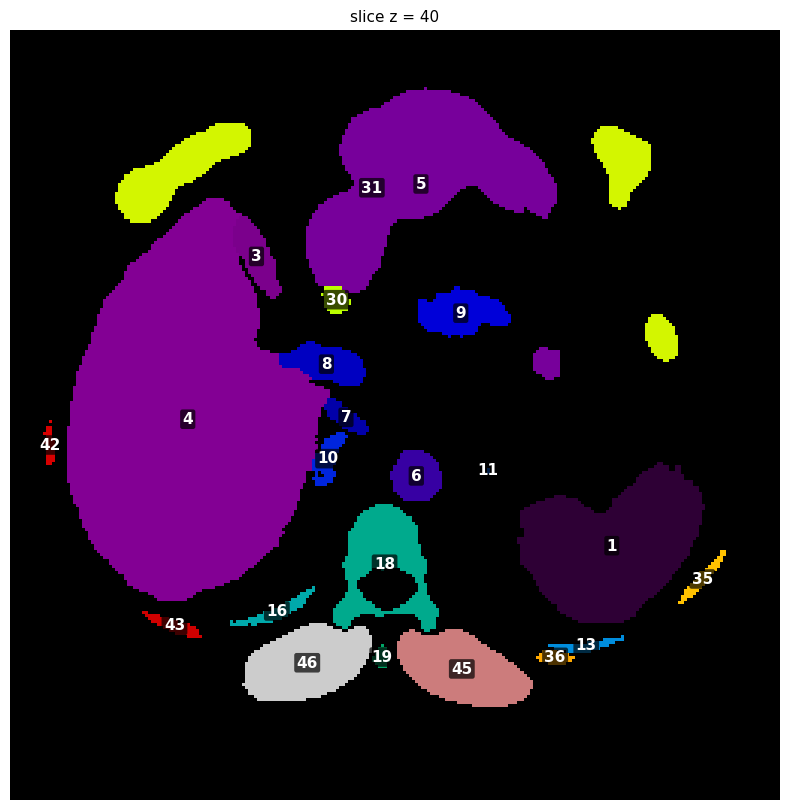

In [116]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ---------- 数据准备 ----------
raw = np.asarray(seg_image.data)              # (Z, Y, X)
seg_xyz = np.transpose(raw, (2, 1, 0))        # (X, Y, Z)

# 从 overlay_info 拿 segment 名称（注意多了一层 list）
segs = overlay_info["segmentAttributes"]
while isinstance(segs, list) and len(segs) == 1 and isinstance(segs[0], list):
    segs = segs[0]

# 编号 -> 名称 映射
id2name = {int(s["labelID"]): s["SegmentLabel"] for s in segs}
print("=== 编号 -> 名称 对照表 ===")
for k in sorted(id2name):
    print(f"  {k:3d} : {id2name[k]}")

# 每个 segment 的体素数（用来看哪些在实际数据里出现过）
labels_present = [int(l) for l in np.unique(seg_xyz) if l != 0]
print("\n=== 实际出现在数据里的 label ===")
for lbl in labels_present:
    n = int((seg_xyz == lbl).sum())
    print(f"  {lbl:3d} ({id2name.get(lbl, '?'):35s}) voxels={n}")


# ---------- 可视化：在图上标编号 ----------
def show_slice_with_labels(z, ax=None, fontsize=9):
    """显示第 z 层，并在每个 segment 的质心处标上 labelID。"""
    if ax is None:
        ax = plt.gca()
    slice_2d = seg_xyz[:, :, z]                # (X, Y)
    ax.imshow(slice_2d.T, cmap="nipy_spectral",
              origin="lower", interpolation="nearest")
    ax.set_title(f"slice z = {z}", fontsize=11)
    ax.axis("off")

    # 在这一层出现过的 label
    for lbl in np.unique(slice_2d):
        lbl = int(lbl)
        if lbl == 0:
            continue
        ys, xs = np.where(slice_2d == lbl)     # 注意：索引是 (x, y)
        if len(xs) < 3:
            continue                            # 太小不标
        cx, cy = xs.mean(), ys.mean()           # 质心（X, Y）
        # 图上坐标：imshow 里 x=列(Y)，y=行(X)
        ax.text(cy, cx, str(lbl),
                color="white", fontsize=fontsize, fontweight="bold",
                ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.15",
                          facecolor="black", alpha=0.7, edgecolor="none"))


# ---------- 1. 多层栅格，每层都标编号 ----------
# zs = [int(v) for v in np.linspace(0, seg_xyz.shape[2] - 1, 8)]
# fig, axes = plt.subplots(2, 4, figsize=(20, 10))
# for ax, z in zip(axes.ravel(), zs):
#     show_slice_with_labels(z, ax=ax, fontsize=8)
# plt.suptitle("每层 labelID 标注（对照上方编号表查看）", fontsize=14)
# plt.tight_layout()
# plt.show()


# ---------- 2. 单层大图（改 z 值看不同层） ----------
z = seg_xyz.shape[2] // 2
z = 40
plt.figure(figsize=(10, 10))
show_slice_with_labels(z, fontsize=11)
plt.show()




In [102]:
direction = np.array(seg_image.direction).reshape(3, 3)
print(direction)

[[ 1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]



show only label 12 : Left Upper lobe of lung


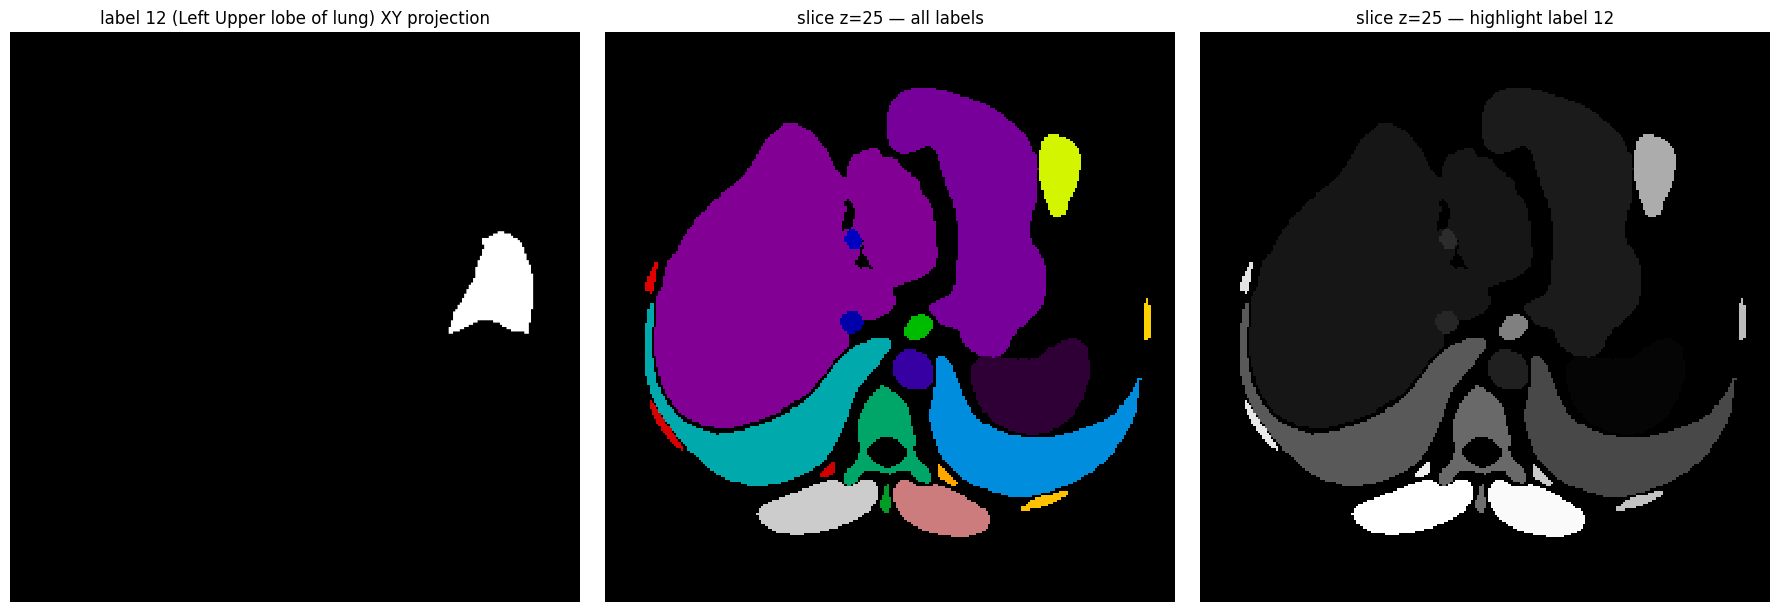

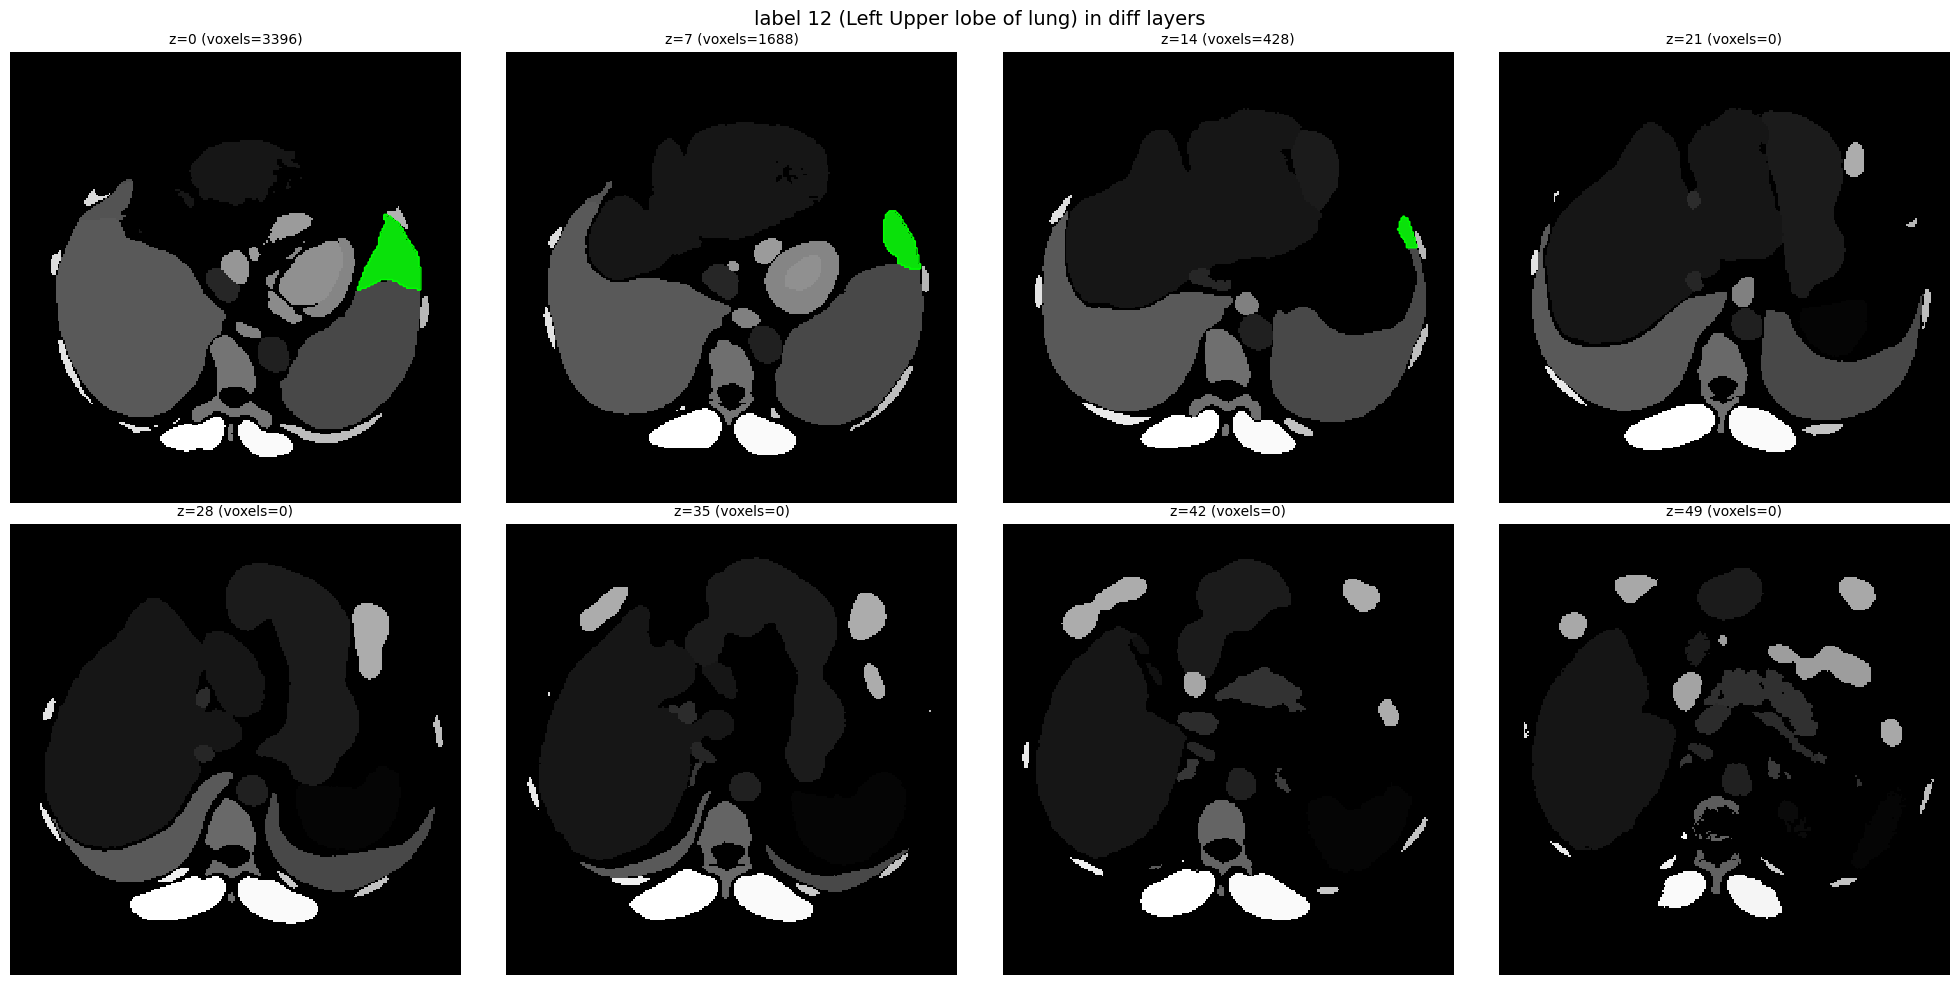

In [115]:
# ---------- 3. 单独把某个 label 高亮出来 ----------
from matplotlib.colors import ListedColormap

target = labels_present[11]          # 改成你想看的编号，如 4 = Liver
print(f"\nshow only label {target} : {id2name.get(target, '?')}")

# 目标 label 的 3D 掩膜（bool, shape=(X, Y, Z)）
mask3d = (seg_xyz == target)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ---- (左) 3D MIP 投影：看这个 segment 整体位置 ----
proj_xy = mask3d.any(axis=2)         # 沿 Z 投影，bool (X, Y)
axes[0].imshow(proj_xy.T, cmap="gray", origin="lower")
axes[0].set_title(f"label {target} ({id2name.get(target,'?')}) XY projection")
axes[0].axis("off")

# ---- (中) 中间层：所有 label 伪彩显示 ----
z = seg_xyz.shape[2] // 2
slice_2d = seg_xyz[:, :, z]          # (X, Y)
axes[1].imshow(slice_2d.T, cmap="nipy_spectral",
               origin="lower", interpolation="nearest")
axes[1].set_title(f"slice z={z} — all labels")
axes[1].axis("off")

# ---- (右) 中间层：灰底 + 绿色高亮 + 轮廓 ----
mask_2d = (slice_2d == target)       # bool (X, Y)

# 背景：整层灰度
axes[2].imshow(slice_2d.T, cmap="gray",
               origin="lower", interpolation="nearest")

# 高亮：mask 为 0 的地方透明，为 1 的地方亮绿
green_cmap = ListedColormap(["#00FF00"])
masked = np.ma.masked_where(~mask_2d.T, mask_2d.T)
axes[2].imshow(masked, cmap=green_cmap,
               origin="lower", alpha=0.85, interpolation="nearest")

# 轮廓线：边界更清楚
if mask_2d.any():
    axes[2].contour(mask_2d.T.astype(float), levels=[0.5],
                    colors="#00FF00", linewidths=1.5,
                    origin="lower")

axes[2].set_title(f"slice z={z} — highlight label {target}")
axes[2].axis("off")

plt.tight_layout()
plt.show()


# ---------- 附加：多层高亮，看这个 label 在哪些层出现 ----------
zs = [int(v) for v in np.linspace(0, seg_xyz.shape[2] - 1, 8)]
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, z in zip(axes.ravel(), zs):
    slice_2d = seg_xyz[:, :, z]
    mask_2d = (slice_2d == target)

    ax.imshow(slice_2d.T, cmap="gray", origin="lower",
              interpolation="nearest")
    if mask_2d.any():
        masked = np.ma.masked_where(~mask_2d.T, mask_2d.T)
        ax.imshow(masked, cmap=green_cmap, origin="lower",
                  alpha=0.85, interpolation="nearest")
        ax.contour(mask_2d.T.astype(float), levels=[0.5],
                   colors="#00FF00", linewidths=1.0, origin="lower")

    n = int(mask_2d.sum())
    ax.set_title(f"z={z} (voxels={n})", fontsize=10)
    ax.axis("off")

plt.suptitle(f"label {target} ({id2name.get(target,'?')}) in diff layers",
             fontsize=14)
plt.tight_layout()
plt.show()

## 6. Check Licenses Before Using Data

IDC collections use a variety of open licenses, although >95% of data is covered by CC-BY licenses. The license governs what you can do with the data — for example:
- **CC BY** — freely use, modify, and redistribute with attribution (most permissive)
- **CC BY-NC** — non-commercial use only with attribution

Always check the license before training models or publishing results. The `license_short_name` column in the `index` table makes this a simple SQL query.

In [21]:
# Always check licenses before use
uid_list = ", ".join(f"'{uid}'" for uid in series_uids)
licenses = client.sql_query(f"""
    SELECT license_short_name, COUNT(*) as count
    FROM index WHERE SeriesInstanceUID IN ({uid_list})
    GROUP BY license_short_name
""")
print("Licenses:")
print(licenses.to_string(index=False))

Licenses:
license_short_name  count
         CC BY 4.0      3


## 7. Cleanup

In [ ]:
# import shutil; shutil.rmtree(data_dir)  # Uncomment to delete
print(f"Data at: {data_dir}")

Data at: /tmp/idc_monai_saoiqlhn


## Summary

This tutorial demonstrated:
1. Querying IDC with `idc-index` SQL — no cloud account needed, queries run locally
2. Downloading DICOM images and segmentations with `download_from_selection()`
3. Loading CT images into MONAI with `LoadImaged` and `ITKReader`
4. Finding image–segmentation pairs via `seg_index`
5. Loading DICOM-SEG files with a custom `LoadDicomSegd` transform
6. Extracting per-segment metadata (names, categories, standardized codes)
7. Using DICOM SEG recommended colors for anatomically meaningful visualization

**Key IDC Concepts:**
- **`index` table** — one row per DICOM series; the starting point for all queries
- **Supplemental indexes** (`collections_index`, `seg_index`, `volume_geometry_index`) — loaded on demand via `fetch_index()` for specialized metadata
- **No auth required** — all IDC data is publicly accessible; just install `idc-index` and query

**Key DICOM-SEG Concepts:** Each segment in a DICOM-SEG file carries:
- `SegmentLabel` — Human-readable name (e.g., "Liver")
- `SegmentedPropertyCategoryCodeSequence` — Category (e.g., "Anatomical Structure")
- `SegmentedPropertyTypeCodeSequence` — Type with standardized codes (SNOMED-CT, RadLex, etc.)
- `recommendedDisplayRGBValue` — Suggested display color baked into the DICOM file

**Resources:**
- [IDC Tutorials](https://github.com/ImagingDataCommons/IDC-Tutorials) - Self-guided Google Colab notebooks
- [IDC Portal](https://portal.imaging.datacommons.cancer.gov/) — Interactive browser for exploring collections
- [IDC Documentation](https://learn.canceridc.dev/) — Full documentation and tutorials
- [IDC User Forum](https://discourse.canceridc.dev/) — Community support from IDC maintainers
- [idc-index on GitHub](https://github.com/ImagingDataCommons/idc-index) — Package source and issue tracker
- [ITKWasm DICOM](https://wasm.itk.org/en/latest/introduction/file_formats/dicom.html)
- [idc-claude-skill](https://github.com/ImagingDataCommons/idc-claude-skill) — an AI assistant skill for navigating IDC data and the `idc-index` API.